# The fact was in the context, and the model did not read it

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/llmops-genai-platform/context-packing/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=llmops-genai-platform/context-packing/demo.ipynb)

A RAG answer is generated from a window: the instruction, the retrieved chunks a packer kept under a token
budget in the order it chose, then the question. The eval column that describes the window is *context recall*,
the share of needed facts physically present. The model does not read every position equally well: Liu et al.
(2023, "Lost in the Middle") measured a U over position that sinks as the context grows, and an instruction at
the top is obeyed less the further it sits from the question. This notebook declares a seeded query log and a
reading model, scores four packing policies exactly, checks the exact numbers against a raw simulation, and
shows the dashboard ranking the policies in the opposite order from the answers.

1. The log and the reading model
2. Calibration - exact expectation vs raw simulation
3. Four policies, three numbers
4. Where the answers went - three failure classes
5. The budget sweep
6. Same chunks, different order
7. Try your own

## The engine

Extracted from `packing.py` at build time, character for character. `make_log` is the declared query log;
`read(u, L)` and `comply(d)` are the reading model; `select`, `arrange` and `window` are the packer;
`score_query` and `evaluate` are the exact rates; `simulate` and `calibrate` are the raw check.

In [1]:
from __future__ import annotations

import math
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np

SEED = 192


MC_REPS = 200  # replicates per query; x 2,000 queries = 400,000 trials per rate


Q = 2_000          # queries in the declared log


N_CAND = 30        # candidate chunks the retriever returns per query, best first


LEN_RANGE = (120, 520)                       # chunk length in tokens, uniform


FACTS_NEEDED = {1: 0.60, 2: 0.30, 3: 0.10}   # how many distinct facts the answer needs


RANK_DECAY = 0.82                            # P(gold chunk at rank r) proportional to RANK_DECAY ** r


MISS_RATE = 0.06                             # the fact's chunk is not in the top N_CAND at all


INSTRUCTION_TOKENS = 180


QUESTION_TOKENS = 60


L0 = 4_000


LIU_POINTS = (0.76, 0.54, 0.66)   # read probability at first / middle / last position when L = L0


LENGTH_SLOPE = 0.025              # every position loses this per 1,000 tokens of window beyond L0


READ_FLOOR, READ_CEIL = 0.05, 0.98


COMPLY_AT_ZERO, COMPLY_SLOPE, COMPLY_FLOOR = 0.98, 0.03, 0.30


POLICIES: Dict[str, Dict] = {
    "v1 rank, 4k":            {"budget": 4_000, "order": "rank", "instruction": "top"},
    "v2 rank, 12k":           {"budget": 12_000, "order": "rank", "instruction": "top"},
    "v3 reorder, 4k":         {"budget": 4_000, "order": "reorder", "instruction": "top"},
    "v4 reorder+repeat, 4k":  {"budget": 4_000, "order": "reorder", "instruction": "both"},
}


def make_log(q: int = Q, seed: int = SEED) -> List[Dict]:
    """The declared query log. Each query: candidate lengths (best rank first), and the rank of each needed
    fact's chunk (None when the retriever missed it). Ranks of distinct facts are distinct."""
    rng = np.random.default_rng(seed)
    ks = list(FACTS_NEEDED)
    pk = np.array([FACTS_NEEDED[k] for k in ks])
    pr = RANK_DECAY ** np.arange(1, N_CAND + 1)
    pr = pr / pr.sum()
    log = []
    for _ in range(q):
        lens = rng.integers(LEN_RANGE[0], LEN_RANGE[1] + 1, N_CAND).tolist()
        k = int(rng.choice(ks, p=pk))
        ranks: List[Optional[int]] = []
        taken: set = set()
        for _f in range(k):
            if rng.random() < MISS_RATE:
                ranks.append(None)
                continue
            r = int(rng.choice(N_CAND, p=pr)) + 1
            while r in taken:
                r = int(rng.choice(N_CAND, p=pr)) + 1
            taken.add(r)
            ranks.append(r)
        log.append({"lens": lens, "gold": ranks})
    return log


def curve(u: float, pts: Tuple[float, float, float] = LIU_POINTS) -> float:
    """Quadratic through (0, first), (0.5, middle), (1, last)."""
    a, b, c = pts
    return a * (1 - u) * (1 - 2 * u) + 4 * b * u * (1 - u) + c * u * (2 * u - 1)


def read(u: float, total_tokens: int) -> float:
    p = curve(u) - LENGTH_SLOPE * (total_tokens - L0) / 1000.0
    return min(READ_CEIL, max(READ_FLOOR, p))


def comply(distance_tokens: int) -> float:
    p = COMPLY_AT_ZERO - COMPLY_SLOPE * distance_tokens / 1000.0
    return min(1.0, max(COMPLY_FLOOR, p))


def select(lens: Sequence[int], budget: int, instruction: str) -> List[int]:
    """Ranks (1-based) kept: walk the candidates best first, keep each that still fits. Fixed costs come off
    the budget first."""
    fixed = INSTRUCTION_TOKENS * (2 if instruction == "both" else 1) + QUESTION_TOKENS
    room = budget - fixed
    kept = []
    for i, ln in enumerate(lens):
        if ln <= room:
            kept.append(i + 1)
            room -= ln
    return kept


def arrange(kept: Sequence[int], order: str) -> List[int]:
    """The order the kept ranks appear in the window, top to bottom."""
    k = list(kept)
    if order == "rank":
        return k
    if order == "reverse":
        return k[::-1]
    if order == "reorder":
        front, back = k[0::2], k[1::2]
        return front + back[::-1]
    raise ValueError(f"unknown order {order!r}")


def window(lens: Sequence[int], policy: Dict) -> Dict:
    """Everything about the packed window: the layout, each kept rank's relative position, total tokens, and
    the distance from the nearest instruction copy to the question."""
    kept = select(lens, policy["budget"], policy["instruction"])
    layout = arrange(kept, policy["order"])
    chunk_tokens = sum(lens[r - 1] for r in layout)
    copies = 2 if policy["instruction"] == "both" else 1
    total = INSTRUCTION_TOKENS * copies + chunk_tokens + QUESTION_TOKENS
    pos: Dict[int, float] = {}
    start = 0
    span = chunk_tokens - (lens[layout[-1] - 1] if layout else 0)   # first chunk starts at 0, last at span
    for r in layout:
        pos[r] = start / span if span > 0 else 0.0
        start += lens[r - 1]
    distance = 0 if copies == 2 else chunk_tokens
    return {"kept": kept, "layout": layout, "pos": pos, "total": total, "distance": distance}


def score_query(entry: Dict, policy: Dict) -> Dict:
    """Exact per-query expectations under the reading model."""
    w = window(entry["lens"], policy)
    present = [r is not None and r in w["pos"] for r in entry["gold"]]
    reads = [read(w["pos"][r], w["total"]) if ok else 0.0 for r, ok in zip(entry["gold"], present)]
    c = comply(w["distance"])
    all_present = all(present)
    all_read = math.prod(reads) if all_present else 0.0
    return {
        "present_sum": sum(present),
        "read_sum": sum(reads),
        "answer": c * all_read,
        "tokens": w["total"],
        "comply": c,
        # failure decomposition: the three parts sum to 1 - answer
        "fail_missing": 0.0 if all_present else 1.0,
        "fail_unread": (1.0 - all_read) if all_present else 0.0,
        "fail_ignored": all_read * (1.0 - c),
        "gold_positions": [w["pos"][r] for r, ok in zip(entry["gold"], present) if ok],
        "n_kept": len(w["kept"]),
    }


def evaluate(policy: Dict, log: Sequence[Dict]) -> Dict:
    """Recalls are pooled over FACTS (a query needing three facts contributes three); the answer rate and the
    failure classes are per QUERY. The first version averaged per-query recalls and the raw simulation pooled
    facts, so a quantity with no randomness in it read as outside its own interval - the two readers of one
    number disagreed. One definition now, and the calibration no longer checks the deterministic column."""
    rows = [score_query(e, policy) for e in log]
    n = len(rows)
    facts = sum(len(e["gold"]) for e in log)
    gp = [u for r in rows for u in r["gold_positions"]]
    mid = sum(1 / 3 <= u <= 2 / 3 for u in gp) / len(gp) if gp else 0.0
    present = sum(r["present_sum"] for r in rows)
    read_sum = sum(r["read_sum"] for r in rows)
    return {
        "context_recall": present / facts,
        "effective_recall": read_sum / facts,
        "answer_rate": sum(r["answer"] for r in rows) / n,
        "compliance": sum(r["comply"] for r in rows) / n,
        "tokens_per_query": sum(r["tokens"] for r in rows) / n,
        "chunks_per_query": sum(r["n_kept"] for r in rows) / n,
        "fail_missing": sum(r["fail_missing"] for r in rows) / n,
        "fail_unread": sum(r["fail_unread"] for r in rows) / n,
        "fail_ignored": sum(r["fail_ignored"] for r in rows) / n,
        "gold_in_middle_third": mid,
        "read_given_present": read_sum / present if present else 0.0,
        "facts": facts,
    }


def sweep(budgets: Sequence[int], log: Sequence[Dict], order: str = "rank", instruction: str = "top") -> List[Dict]:
    out = []
    for b in budgets:
        e = evaluate({"budget": b, "order": order, "instruction": instruction}, log)
        out.append({"budget": b, **{k: e[k] for k in ("context_recall", "effective_recall", "answer_rate",
                                                      "compliance", "tokens_per_query")}})
    return out


def same_set_different_order(log: Sequence[Dict], a: Dict, b: Dict) -> Dict:
    """Two policies with the same budget and instruction keep the SAME chunks for every query; only the order
    differs. Everything the retrieval log records is identical; the answer rate is not."""
    assert a["budget"] == b["budget"] and a["instruction"] == b["instruction"]
    same = all(window(e["lens"], a)["kept"] == window(e["lens"], b)["kept"] for e in log)
    ea, eb = evaluate(a, log), evaluate(b, log)
    return {"identical_sets": same, "context_recall_gap": eb["context_recall"] - ea["context_recall"],
            "tokens_gap": eb["tokens_per_query"] - ea["tokens_per_query"],
            "answer_rate_gap": eb["answer_rate"] - ea["answer_rate"],
            "gold_in_middle_a": ea["gold_in_middle_third"], "gold_in_middle_b": eb["gold_in_middle_third"]}


def by_rank(policy: Dict, log: Sequence[Dict], max_rank: int = 10) -> List[Dict]:
    """For a needed fact retrieved at rank r: how often it is kept, and how often it is read given kept."""
    out = []
    for r in range(1, max_rank + 1):
        kept = read_p = 0.0
        n = 0
        for e in log:
            if r in e["gold"]:
                n += 1
                w = window(e["lens"], policy)
                if r in w["pos"]:
                    kept += 1
                    read_p += read(w["pos"][r], w["total"])
        out.append({"rank": r, "n": n, "kept": kept / n if n else 0.0, "read_given_kept": read_p / kept if kept else 0.0,
                    "read": read_p / n if n else 0.0})
    return out


def wilson(k: int, n: int, z: float = 2.5758) -> Tuple[float, float]:
    p = k / n
    den = 1 + z * z / n
    mid = (p + z * z / (2 * n)) / den
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return mid - half, mid + half


def simulate(policy: Dict, log: Sequence[Dict], reps: int = MC_REPS, seed: int = SEED) -> Dict[str, Tuple[int, int]]:
    """Raw simulation: for every query and replicate, draw whether each present fact is read and whether the
    instruction is obeyed as Bernoullis. Returns (successes, trials) for a Wilson check of the two exact rates
    that have randomness in them; the present count is deterministic and is asserted instead."""
    rng = np.random.default_rng(seed)
    hits = eff = ans = 0
    facts = 0
    for e in log:
        w = window(e["lens"], policy)
        present = np.array([r is not None and r in w["pos"] for r in e["gold"]])
        p = np.array([read(w["pos"][r], w["total"]) if ok else 0.0 for r, ok in zip(e["gold"], present)])
        c = comply(w["distance"])
        rd = rng.random((reps, len(p))) < p            # present-and-read draws (p is 0 where absent)
        ok = rng.random(reps) < c
        facts += reps * len(p)
        hits += reps * int(present.sum())
        eff += int(rd.sum())
        ans += int((rd.all(axis=1) & ok).sum())
    assert hits == reps * sum(round(evaluate_present(e, policy)) for e in log)
    return {"effective_recall": (eff, facts), "answer_rate": (ans, reps * len(log))}


def evaluate_present(entry: Dict, policy: Dict) -> int:
    """Needed facts present in the window - deterministic, so it is asserted rather than interval-checked."""
    w = window(entry["lens"], policy)
    return sum(r is not None and r in w["pos"] for r in entry["gold"])


def calibrate(log: Sequence[Dict], reps: int = MC_REPS, seed: int = SEED,
              policies: Optional[Dict[str, Dict]] = None) -> List[Dict]:
    rows = []
    for s, (name, pol) in enumerate((policies or POLICIES).items()):
        ex = evaluate(pol, log)
        sim = simulate(pol, log, reps, seed + s)
        for key, (k, n) in sim.items():
            lo, hi = wilson(k, n)
            rows.append({"policy": name, "quantity": key, "exact": ex[key], "mc": k / n, "inside_99": bool(lo <= ex[key] <= hi)})
    return rows


def parse_policy(text: str) -> Dict:
    """`budget, order, instruction` - e.g. `4000, reorder, both`. Order in rank/reorder/reverse, instruction in
    top/both."""
    parts = [p.strip().lower() for p in text.split(",")]
    if len(parts) != 3:
        raise ValueError(f"need 3 comma-separated fields (budget, order, instruction), got {len(parts)}: {text!r}")
    b, order, instr = parts
    try:
        budget = int(b.replace("k", "000").replace("_", ""))
    except ValueError:
        raise ValueError(f"budget did not parse: {b!r}")
    fixed = 2 * INSTRUCTION_TOKENS + QUESTION_TOKENS
    if budget < fixed + LEN_RANGE[0]:
        raise ValueError(f"budget {budget} cannot hold the instruction, the question and one chunk ({fixed + LEN_RANGE[0]})")
    if order not in ("rank", "reorder", "reverse"):
        raise ValueError(f"order must be rank, reorder or reverse, got {order!r}")
    if instr not in ("top", "both"):
        raise ValueError(f"instruction must be top or both, got {instr!r}")
    return {"budget": budget, "order": order, "instruction": instr}

LOG = make_log()
print(f'engine loaded, {len(LOG):,} queries in the log')

engine loaded, 2,000 queries in the log


**Resolution of the instrument.** Every policy number here is an exact expectation over the declared log and
matches `evidence.txt` to the digit. Only the calibration's raw simulation runs at 20 replicates per
query instead of the study's 200.

## 1. The log and the reading model

In [2]:
print("read(u, L): first / middle / last position, then comply with the instruction at the top")
for L in (2_000, 4_000, 8_000, 12_000):
    print(f"  L = {L:>6,}: read first {read(0, L):.3f}  middle {read(0.5, L):.3f}  last {read(1, L):.3f}   "
          f"comply {comply(L - INSTRUCTION_TOKENS - QUESTION_TOKENS):.3f}")
print()
e = LOG[0]
w = window(e["lens"], POLICIES["v1 rank, 4k"])
print(f"query 0 needs facts at ranks {e['gold']}; v1 keeps ranks {w['kept']} in order {w['layout']}, {w['total']} tokens")

read(u, L): first / middle / last position, then comply with the instruction at the top
  L =  2,000: read first 0.810  middle 0.590  last 0.710   comply 0.927
  L =  4,000: read first 0.760  middle 0.540  last 0.660   comply 0.867
  L =  8,000: read first 0.660  middle 0.440  last 0.560   comply 0.747
  L = 12,000: read first 0.560  middle 0.340  last 0.460   comply 0.627

query 0 needs facts at ranks [4]; v1 keeps ranks [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13] in order [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13], 3923 tokens


## 2. Calibration

In [3]:
cal = calibrate(LOG, reps=20)
for r in cal:
    print(f"{r['policy']:<24} {r['quantity']:<17} exact {r['exact']:.4f}   MC {r['mc']:.4f}   "
          f"{'inside' if r['inside_99'] else 'OUTSIDE'}")
print(f"{sum(r['inside_99'] for r in cal)} of {len(cal)} inside their 99% Wilson interval")

v1 rank, 4k              effective_recall  exact 0.5331   MC 0.5309   inside
v1 rank, 4k              answer_rate       exact 0.3713   MC 0.3687   inside
v2 rank, 12k             effective_recall  exact 0.4899   MC 0.4910   inside
v2 rank, 12k             answer_rate       exact 0.2657   MC 0.2667   inside
v3 reorder, 4k           effective_recall  exact 0.5409   MC 0.5417   inside
v3 reorder, 4k           answer_rate       exact 0.3781   MC 0.3782   inside
v4 reorder+repeat, 4k    effective_recall  exact 0.5316   MC 0.5319   inside
v4 reorder+repeat, 4k    answer_rate       exact 0.4165   MC 0.4172   inside
8 of 8 inside their 99% Wilson interval


Context recall has no randomness in it (a fact is in the window or it is not), so the simulation asserts the
count rather than interval-checking it. The first version of this build averaged recall per query while the
simulation pooled facts, and the deterministic column read as OUTSIDE its own interval - two readers of one
number. One definition now.

## 3. Four policies, three numbers

In [4]:
ev = {k: evaluate(p, LOG) for k, p in POLICIES.items()}
print(f"{'policy':<24} {'context recall':>14} {'effective recall':>16} {'answer rate':>11} {'comply':>7} {'tokens':>7} {'chunks':>6}")
for k, e in ev.items():
    print(f"{k:<24} {e['context_recall']:>14.1%} {e['effective_recall']:>16.1%} {e['answer_rate']:>11.1%} "
          f"{e['compliance']:>7.1%} {e['tokens_per_query']:>7.0f} {e['chunks_per_query']:>6.1f}")
v1, v2, v3, v4 = (ev[k] for k in POLICIES)
deltas = {
    "12k window: context recall": v2["context_recall"] - v1["context_recall"],
    "12k window: answer rate": v2["answer_rate"] - v1["answer_rate"],
    "reorder: context recall": v3["context_recall"] - v1["context_recall"],
    "reorder: answer rate": v3["answer_rate"] - v1["answer_rate"],
    "reorder+repeat: context recall": v4["context_recall"] - v1["context_recall"],
    "reorder+repeat: answer rate": v4["answer_rate"] - v1["answer_rate"],
}
print()
for k, d in deltas.items():
    print(f"{k:<32} {d * 100:+6.1f} pts")
print()
print("by context recall: " + " > ".join(sorted(ev, key=lambda k: -ev[k]["context_recall"])))
print("by answer rate:    " + " > ".join(sorted(ev, key=lambda k: -ev[k]["answer_rate"])))

policy                   context recall effective recall answer rate  comply  tokens chunks
v1 rank, 4k                       83.0%            53.3%       37.1%   86.9%    3943   12.0
v2 rank, 12k                      92.9%            49.0%       26.6%   69.2%    9842   30.0
v3 reorder, 4k                    83.0%            54.1%       37.8%   86.9%    3943   12.0
v4 reorder+repeat, 4k             81.6%            53.2%       41.6%   98.0%    3941   11.4

12k window: context recall         +9.9 pts
12k window: answer rate           -10.6 pts
reorder: context recall            +0.0 pts
reorder: answer rate               +0.7 pts
reorder+repeat: context recall     -1.4 pts
reorder+repeat: answer rate        +4.5 pts

by context recall: v2 rank, 12k > v1 rank, 4k > v3 reorder, 4k > v4 reorder+repeat, 4k
by answer rate:    v4 reorder+repeat, 4k > v3 reorder, 4k > v1 rank, 4k > v2 rank, 12k


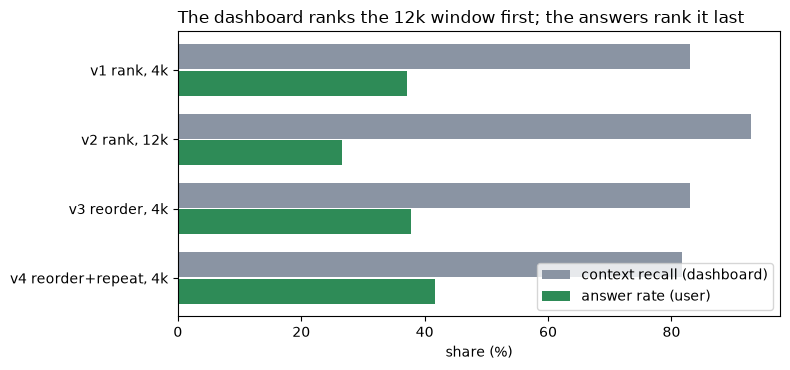

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.8))
names = list(ev)
ys = np.arange(len(names))[::-1]
ax.barh(ys + 0.19, [ev[n]["context_recall"] * 100 for n in names], 0.36, color="#8a94a3", label="context recall (dashboard)")
ax.barh(ys - 0.19, [ev[n]["answer_rate"] * 100 for n in names], 0.36, color="#2e8b57", label="answer rate (user)")
ax.set_yticks(ys); ax.set_yticklabels(names); ax.set_xlabel("share (%)"); ax.legend(loc="lower right")
ax.set_title("The dashboard ranks the 12k window first; the answers rank it last", loc="left")
plt.tight_layout(); plt.savefig("notebook_chart.png", dpi=120); plt.show()

Tripling the budget puts 10 more points of needed facts into the window and takes 11 points off the answer rate:
every position reads worse in a longer window, and the instruction at the top is obeyed 69% of the time instead
of 87%. Repeating the instruction before the question costs one chunk (context recall falls 1.4 points) and
gains 4.5 points of answers. The dashboard scores the first change up and the second down.

## 4. Where the answers went

In [6]:
print(f"{'policy':<24} {'retrieval miss':>14} {'present, unread':>16} {'instruction ignored':>19}")
for k, e in ev.items():
    print(f"{k:<24} {e['fail_missing']:>14.1%} {e['fail_unread']:>16.1%} {e['fail_ignored']:>19.1%}")
print()
print(f"v1: the largest failure class is a fact that WAS in the window ({v1['fail_unread']:.1%} of queries); "
      "context recall counts it as a success")

policy                   retrieval miss  present, unread instruction ignored
v1 rank, 4k                       23.4%            33.9%                5.6%
v2 rank, 12k                      10.2%            51.4%               11.8%
v3 reorder, 4k                    23.4%            33.1%                5.7%
v4 reorder+repeat, 4k             25.3%            32.2%                0.8%

v1: the largest failure class is a fact that WAS in the window (33.9% of queries); context recall counts it as a success


The three classes sum to one minus the answer rate. Context recall measures the first; the other two are
invisible to it, and the larger of them is the one it cannot see.

## 5. The budget sweep

In [7]:
budgets = [1_000, 1_500, 2_000, 3_000, 4_000, 5_000, 6_000, 8_000, 10_000, 12_000]
for name, (order, instr) in {"rank, top": ("rank", "top"), "reorder, both": ("reorder", "both")}.items():
    rows = sweep(budgets, LOG, order, instr)
    best = max(rows, key=lambda r: r["answer_rate"])
    print(f"{name}: context recall {rows[0]['context_recall']:.1%} -> {rows[-1]['context_recall']:.1%}, never falls; "
          f"answer rate peaks at {best['budget']:,} tokens ({best['answer_rate']:.1%}) and is {rows[-1]['answer_rate']:.1%} at 12k")

rank, top: context recall 34.0% -> 92.9%, never falls; answer rate peaks at 4,000 tokens (37.1%) and is 26.6% at 12k
reorder, both: context recall 26.8% -> 92.9%, never falls; answer rate peaks at 5,000 tokens (43.4%) and is 37.3% at 12k


Context recall is monotone in the budget, so a dashboard built on it can only ever recommend a bigger window.
The answer rate has an interior maximum.

## 6. Same chunks, different order

In [8]:
sd = same_set_different_order(LOG, POLICIES["v1 rank, 4k"], POLICIES["v3 reorder, 4k"])
print(f"identical kept sets on all {Q:,} queries: {sd['identical_sets']};  context recall gap {sd['context_recall_gap']:+.4f};  "
      f"tokens gap {sd['tokens_gap']:+.1f}")
print(f"gold chunks in the middle third: {sd['gold_in_middle_a']:.1%} -> {sd['gold_in_middle_b']:.1%};  "
      f"answer rate gap {sd['answer_rate_gap'] * 100:+.1f} pts")
print()
v1r = {r["rank"]: r for r in by_rank(POLICIES["v1 rank, 4k"], LOG, 5)}
v3r = {r["rank"]: r for r in by_rank(POLICIES["v3 reorder, 4k"], LOG, 5)}
for r in range(1, 6):
    print(f"rank {r}: read {v1r[r]['read']:.3f} under rank order, {v3r[r]['read']:.3f} under reorder")

identical kept sets on all 2,000 queries: True;  context recall gap +0.0000;  tokens gap +0.0
gold chunks in the middle third: 24.2% -> 12.8%;  answer rate gap +0.7 pts

rank 1: read 0.761 under rank order, 0.761 under reorder
rank 2: read 0.694 under rank order, 0.661 under reorder
rank 3: read 0.641 under rank order, 0.693 under reorder
rank 4: read 0.598 under rank order, 0.614 under reorder
rank 5: read 0.568 under rank order, 0.639 under reorder


Nothing the retrieval log records distinguishes the two policies, and the answer rate moves. It moves very
little: the published mitigation halves the share of needed chunks in the middle third, but it also sends the
rank-2 chunk from second-from-top to the far end, where it reads worse, and 39% of needed facts sit at rank 1 or 2.

## Summary

| claim | what the numbers say |
|---|---|
| "context recall is 83%" | and 34% of queries lose a fact that was in the window; the answer rate is 37% |
| "a bigger window will fix it" | 12k: context recall +9.6 pts, answers -10.6 pts; the dashboard ranks it first |
| "reorder for lost-in-the-middle" | same chunks, same recall, +0.7 pts: rank 2 moves to the far end |
| "repeat the instruction" | context recall -1.4 pts, answers +4.5 pts; the dashboard scores it down |
| "more context recall is better" | it is monotone in the budget; the answer rate peaks at 4-5k |

## 7. Try your own

In [9]:
# for text in ("3000, rank, top", "3000, reorder, both", "8000, reverse, both"):
#     e = evaluate(parse_policy(text), LOG)
#     print(f"{text:<22} context recall {e['context_recall']:.1%}  answer rate {e['answer_rate']:.1%}  "
#           f"unread {e['fail_unread']:.1%}  tokens {e['tokens_per_query']:.0f}")
print("uncomment to explore")

uncomment to explore


---

**Built by Phoebe Fu** - one mini product a day. [Repo](https://github.com/phoebefu6/phoebe-the-builder) ·
[This build](llmops-genai-platform/context-packing)

Streamlit version, where you describe your own packing policies:

```bash
pip install -r requirements.txt
streamlit run app.py
```

Sibling builds: [`chunk-optimizer`](../chunk-optimizer) chooses how to cut documents
into chunks; this build asks what happens to the chunks once they are in the window. [`rag-eval`](../rag-eval)
reports context recall; this is the number it leaves out. [`rag-staleness`](../rag-staleness) is the previous
day's audit of a metric that ranked the fixes backwards.